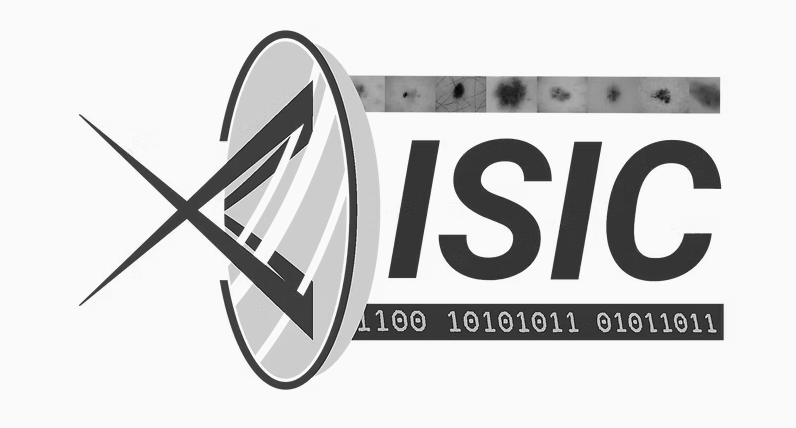

# **ISIC Melanoma Image Segmentation**

In [10]:
from torch.utils.data import Dataset, DataLoader
import cv2
import numpy as np
from tqdm import tqdm
import os
import PIL.Image as Image
import matplotlib.pyplot as plt


## 0. Visualize samples

In [11]:
mask_sample_path = "/home/ruiz/Repositories/VPC/isic_segmentation/ground_truth/ISIC_0000000_segmentation.png"
image_sample_path = "/home/ruiz/Repositories/VPC/isic_segmentation/images_segmentation/ISIC_0000000.jpg"

mask_sample = cv2.imread(mask_sample_path, cv2.IMREAD_GRAYSCALE)
image_sample = cv2.imread(image_sample_path)
image_sample = cv2.cvtColor(image_sample, cv2.COLOR_BGR2RGB)

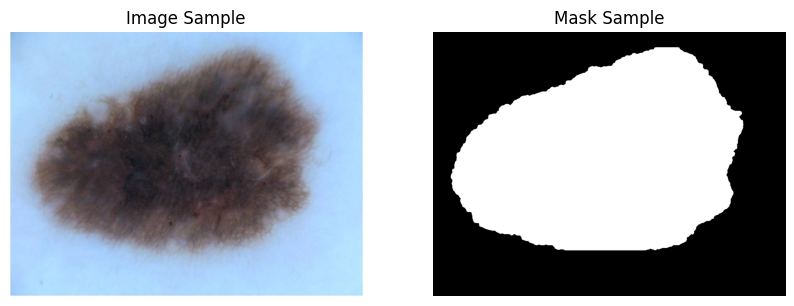

In [12]:
image_sample = Image.open(image_sample_path).convert("RGB")
mask_sample = Image.open(mask_sample_path).convert("L")

#show the image and mask samples
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Image Sample")
plt.imshow(image_sample)
plt.axis("off")
plt.subplot(1, 2, 2)
plt.title("Mask Sample")
plt.imshow(mask_sample, cmap="gray")
plt.axis("off")
plt.show()

## 1. Create the Dataset class

The implementation relies on the following directory structure:
```
├── Isic Segmentation.ipynb
├── isic_segmentation
│   ├── ground_truth
│   │   ├── ISIC_0000000_segmentation.png
│   │   ├── ISIC_0000001_segmentation.png
│   │   ├── ...
│   ├── images_segmentation
│   │   ├── ISIC_0000000.jpg
│   │   ├── ISIC_0000001.jpg
│   │   ├── ...
```

In [13]:
class ISICDataset(Dataset):
    
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = self.load_image(self.image_paths[idx])
        mask = self.load_mask(self.mask_paths[idx])

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        return image, mask

    def load_image(self, path):
        image = cv2.imread(path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        return image

    def load_mask(self, path):
        mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        return mask


In [14]:
images_path = "/home/ruiz/Repositories/VPC/isic_segmentation/images_segmentation/"
masks_path = "/home/ruiz/Repositories/VPC/isic_segmentation/ground_truth/"

image_paths = [images_path + f for f in sorted(os.listdir(images_path))]
mask_paths = [masks_path + f for f in sorted(os.listdir(masks_path))]

dataset = ISICDataset(image_paths, mask_paths)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)


## 2. Use the existing dataset with an 80/20 split and define the U-Net


In [15]:
import torch
from torch import nn
from torch.utils.data import Subset
from tqdm.auto import tqdm

try:
    import albumentations as A
except ImportError as exc:
    raise ImportError("Albumentations is required in the notebook kernel. Install it with `pip install albumentations`.") from exc

SEED = 42
IMAGE_SIZE = (256, 256)
BATCH_SIZE = 32
NUM_EPOCHS = 40
LEARNING_RATE = 8e-4
NUM_WORKERS = 16
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(SEED)
np.random.seed(SEED)

if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True

class AlbumentationsTransform:
    def __init__(self, image_size=IMAGE_SIZE, augment=False):
        resize_h, resize_w = image_size
        if augment:
            self.transform = A.Compose([
                A.Resize(height=resize_h, width=resize_w),
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.2),
                A.RandomRotate90(p=0.5),
                A.OneOf([
                    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=1.0),
                    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=1.0),
                    A.GaussianBlur(blur_limit=(3, 5), p=1.0),
                ], p=0.35),
            ])
        else:
            self.transform = A.Compose([
                A.Resize(height=resize_h, width=resize_w),
            ])

    def __call__(self, image, mask):
        augmented = self.transform(image=image, mask=mask)
        image = augmented["image"]
        mask = augmented["mask"]

        image = torch.from_numpy(image.astype(np.float32) / 255.0).permute(2, 0, 1)
        mask = torch.from_numpy((mask > 0).astype(np.float32)).unsqueeze(0)

        return {"image": image, "mask": mask}

train_transform = AlbumentationsTransform(image_size=IMAGE_SIZE, augment=True)
val_transform = AlbumentationsTransform(image_size=IMAGE_SIZE, augment=False)

num_samples = len(dataset.image_paths)
train_size = int(0.8 * num_samples)
val_size = num_samples - train_size
indices = torch.randperm(num_samples, generator=torch.Generator().manual_seed(SEED)).tolist()
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_base_dataset = ISICDataset(dataset.image_paths, dataset.mask_paths, transform=train_transform)
val_base_dataset = ISICDataset(dataset.image_paths, dataset.mask_paths, transform=val_transform)

train_dataset = Subset(train_base_dataset, train_indices)
val_dataset = Subset(val_base_dataset, val_indices)

loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": DEVICE.type == "cuda",
    "persistent_workers": NUM_WORKERS > 0,
}

if NUM_WORKERS > 0:
    loader_kwargs["prefetch_factor"] = 2

train_loader = DataLoader(train_dataset, shuffle=True, **loader_kwargs)
val_loader = DataLoader(val_dataset, shuffle=False, **loader_kwargs)

print(f"Using device: {DEVICE}")
print(f"Workers: {NUM_WORKERS}")
print(f"Pin memory: {loader_kwargs['pin_memory']}")
print("Albumentations medical-image augmentation enabled for train split.")
print(f"Total samples: {num_samples}")
print(f"Train samples (80%): {len(train_dataset)}")
print(f"Validation samples (20%): {len(val_dataset)}")


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=(64, 128, 256, 512)):
        super().__init__()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()

        channels = in_channels
        for feature in features:
            self.downs.append(DoubleConv(channels, feature))
            channels = feature

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        up_channels = features[-1] * 2
        for feature in reversed(features):
            self.ups.append(nn.ConvTranspose2d(up_channels, feature, kernel_size=2, stride=2))
            self.ups.append(DoubleConv(feature * 2, feature))
            up_channels = feature

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip = skip_connections[idx // 2]
            if x.shape[-2:] != skip.shape[-2:]:
                x = nn.functional.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
            x = torch.cat((skip, x), dim=1)
            x = self.ups[idx + 1](x)

        return self.final_conv(x)


model = UNet().to(DEVICE)
model


Using device: cuda
Workers: 16
Pin memory: True
Albumentations medical-image augmentation enabled for train split.
Total samples: 2750
Train samples (80%): 2200
Validation samples (20%): 550


UNet(
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (downs): ModuleList(
    (0): DoubleConv(
      (block): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (1): DoubleConv(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(128, eps=

## 3. Train and validate the model


In [16]:
def segmentation_metrics(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()

    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    tp = (preds * targets).sum(dim=1)
    fp = (preds * (1 - targets)).sum(dim=1)
    fn = ((1 - preds) * targets).sum(dim=1)
    tn = ((1 - preds) * (1 - targets)).sum(dim=1)

    dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    iou = (tp + eps) / (tp + fp + fn + eps)
    precision = (tp + eps) / (tp + fp + eps)
    recall = (tp + eps) / (tp + fn + eps)
    accuracy = (tp + tn + eps) / (tp + tn + fp + fn + eps)

    return {
        "dice": dice.mean(),
        "iou": iou.mean(),
        "precision": precision.mean(),
        "recall": recall.mean(),
        "accuracy": accuracy.mean(),
    }


def run_epoch(loader, model, criterion, optimizer=None, scaler=None, epoch_idx=0):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    tracked_metrics = ["loss", "dice", "iou", "precision", "recall", "accuracy"]
    totals = {name: torch.zeros(1, device=DEVICE) for name in tracked_metrics}

    mode = "Train" if is_training else "Val"
    pbar = tqdm(loader, total=len(loader), desc=f"Epoch {epoch_idx} [{mode}]", leave=False)

    with torch.set_grad_enabled(is_training):
        for step, (images, masks) in enumerate(pbar, start=1):
            images = images.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)

            if is_training:
                optimizer.zero_grad(set_to_none=True)

            with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=DEVICE.type == "cuda"):
                logits = model(images)
                loss = criterion(logits, masks)

            if is_training:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            batch_metrics = segmentation_metrics(logits.detach(), masks)
            totals["loss"] += loss.detach().float()
            for name, value in batch_metrics.items():
                totals[name] += value.float()

            if step % 20 == 0 or step == len(loader):
                pbar.set_postfix({
                    "loss": f"{(totals['loss'] / step).item():.4f}",
                    "dice": f"{(totals['dice'] / step).item():.4f}",
                    "iou": f"{(totals['iou'] / step).item():.4f}",
                })

    return {name: (value / len(loader)).item() for name, value in totals.items()}


criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scaler = torch.amp.GradScaler("cuda", enabled=DEVICE.type == "cuda")
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3,
    threshold=1e-4,
    min_lr=1e-6,
)
history = {
    "train_loss": [], "train_dice": [], "train_iou": [], "train_precision": [], "train_recall": [], "train_accuracy": [],
    "val_loss": [], "val_dice": [], "val_iou": [], "val_precision": [], "val_recall": [], "val_accuracy": [],
    "lr": []
}

for epoch in range(NUM_EPOCHS):
    train_metrics = run_epoch(train_loader, model, criterion, optimizer, scaler, epoch + 1)
    val_metrics = run_epoch(val_loader, model, criterion, epoch_idx=epoch + 1)
    scheduler.step(val_metrics["loss"])
    current_lr = optimizer.param_groups[0]["lr"]

    for name, value in train_metrics.items():
        history[f"train_{name}"].append(value)
    for name, value in val_metrics.items():
        history[f"val_{name}"].append(value)
    history["lr"].append(current_lr)

    print(
        f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | "
        f"train_loss: {train_metrics['loss']:.4f} | train_dice: {train_metrics['dice']:.4f} | train_iou: {train_metrics['iou']:.4f} | "
        f"val_loss: {val_metrics['loss']:.4f} | val_dice: {val_metrics['dice']:.4f} | val_iou: {val_metrics['iou']:.4f} | "
        f"lr: {current_lr:.6f}"
    )


Epoch 01/40 | train_loss: 0.3645 | train_dice: 0.6195 | train_iou: 0.5139 | val_loss: 0.5647 | val_dice: 0.5464 | val_iou: 0.4381 | lr: 0.000800


Epoch 02/40 | train_loss: 0.2497 | train_dice: 0.7282 | train_iou: 0.6278 | val_loss: 0.4771 | val_dice: 0.5914 | val_iou: 0.4727 | lr: 0.000800


Epoch 03/40 | train_loss: 0.2208 | train_dice: 0.7379 | train_iou: 0.6412 | val_loss: 0.2615 | val_dice: 0.7176 | val_iou: 0.6188 | lr: 0.000800


Epoch 04/40 | train_loss: 0.2102 | train_dice: 0.7433 | train_iou: 0.6478 | val_loss: 0.1829 | val_dice: 0.7646 | val_iou: 0.6692 | lr: 0.000800


Epoch 05/40 | train_loss: 0.2004 | train_dice: 0.7589 | train_iou: 0.6626 | val_loss: 0.2139 | val_dice: 0.7265 | val_iou: 0.6241 | lr: 0.000800


...

Epoch 36/40 | train_loss: 0.1276 | train_dice: 0.8524 | train_iou: 0.7709 | val_loss: 0.1106 | val_dice: 0.8618 | val_iou: 0.7832 | lr: 0.000100


Epoch 37/40 | train_loss: 0.1295 | train_dice: 0.8513 | train_iou: 0.7688 | val_loss: 0.1163 | val_dice: 0.8575 | val_iou: 0.7788 | lr: 0.000100


Epoch 38/40 | train_loss: 0.1270 | train_dice: 0.8485 | train_iou: 0.7662 | val_loss: 0.1127 | val_dice: 0.8634 | val_iou: 0.7858 | lr: 0.000100


Epoch 39/40 | train_loss: 0.1266 | train_dice: 0.8506 | train_iou: 0.7686 | val_loss: 0.1136 | val_dice: 0.8621 | val_iou: 0.7845 | lr: 0.000100


Epoch 40/40 | train_loss: 0.1273 | train_dice: 0.8535 | train_iou: 0.7718 | val_loss: 0.1160 | val_dice: 0.8578 | val_iou: 0.7793 | lr: 0.000050


## 4. Visualize the training curves


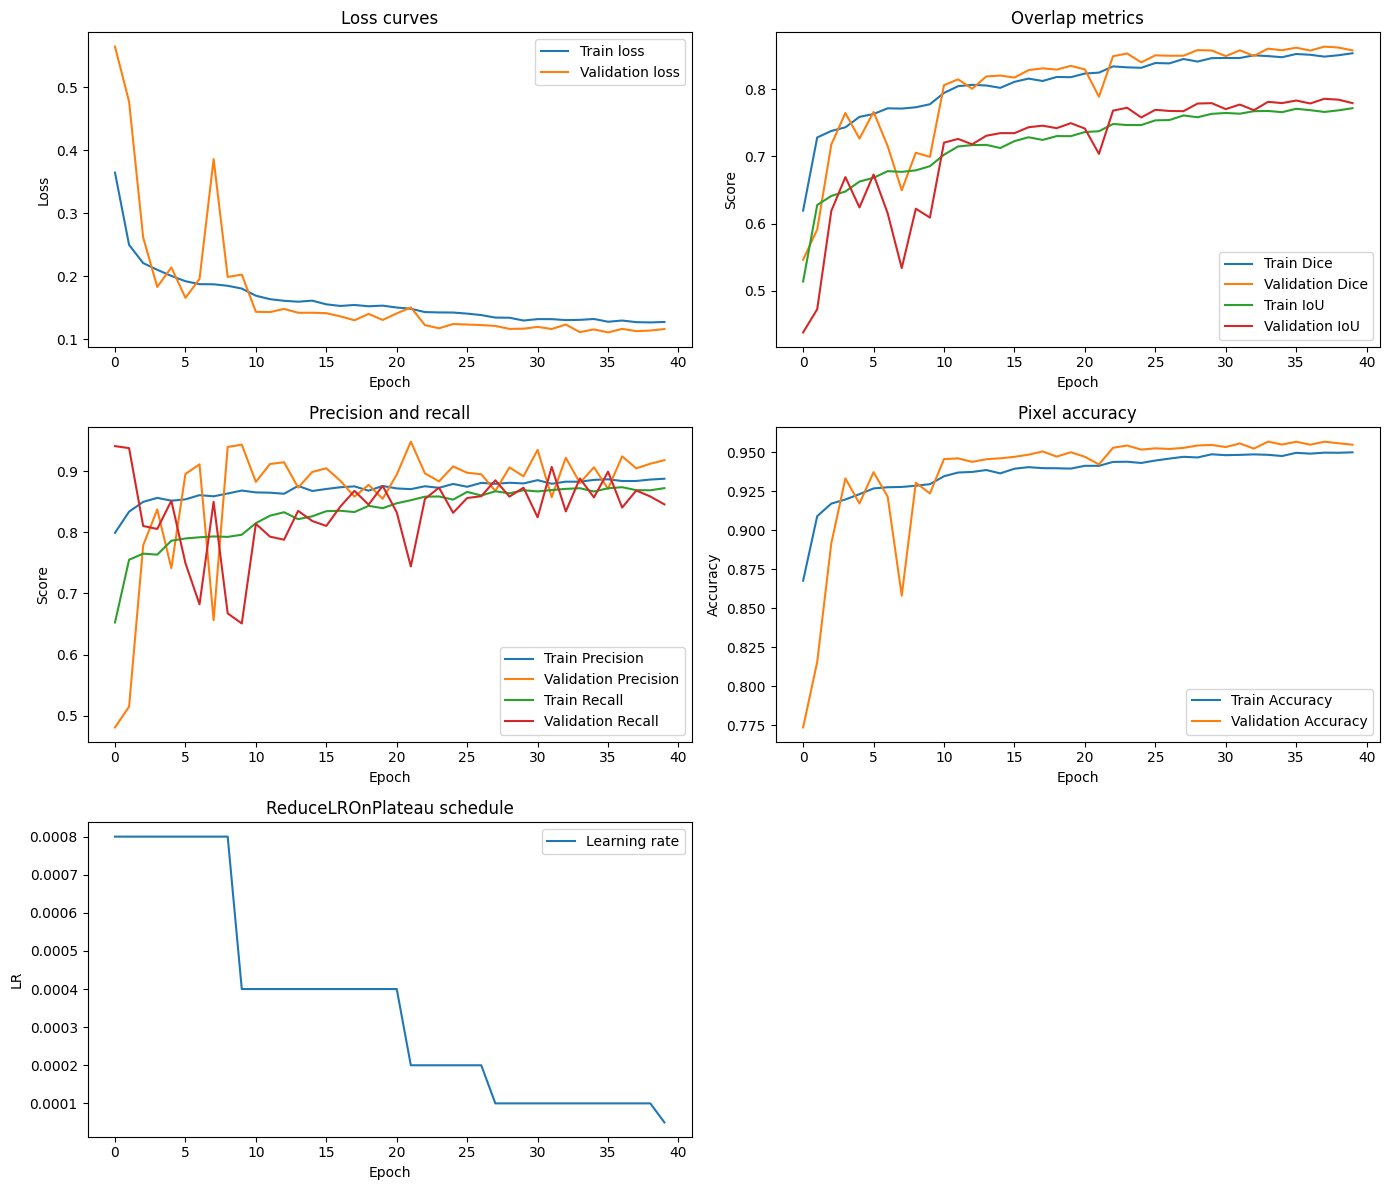

In [17]:
plt.figure(figsize=(14, 12))

plt.subplot(3, 2, 1)
plt.plot(history["train_loss"], label="Train loss")
plt.plot(history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss curves")
plt.legend()

plt.subplot(3, 2, 2)
plt.plot(history["train_dice"], label="Train Dice")
plt.plot(history["val_dice"], label="Validation Dice")
plt.plot(history["train_iou"], label="Train IoU")
plt.plot(history["val_iou"], label="Validation IoU")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Overlap metrics")
plt.legend()

plt.subplot(3, 2, 3)
plt.plot(history["train_precision"], label="Train Precision")
plt.plot(history["val_precision"], label="Validation Precision")
plt.plot(history["train_recall"], label="Train Recall")
plt.plot(history["val_recall"], label="Validation Recall")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Precision and recall")
plt.legend()

plt.subplot(3, 2, 4)
plt.plot(history["train_accuracy"], label="Train Accuracy")
plt.plot(history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Pixel accuracy")
plt.legend()

plt.subplot(3, 2, 5)
plt.plot(history["lr"], label="Learning rate")
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.title("ReduceLROnPlateau schedule")
plt.legend()

plt.subplot(3, 2, 6)
plt.axis("off")

plt.tight_layout()
plt.show()
